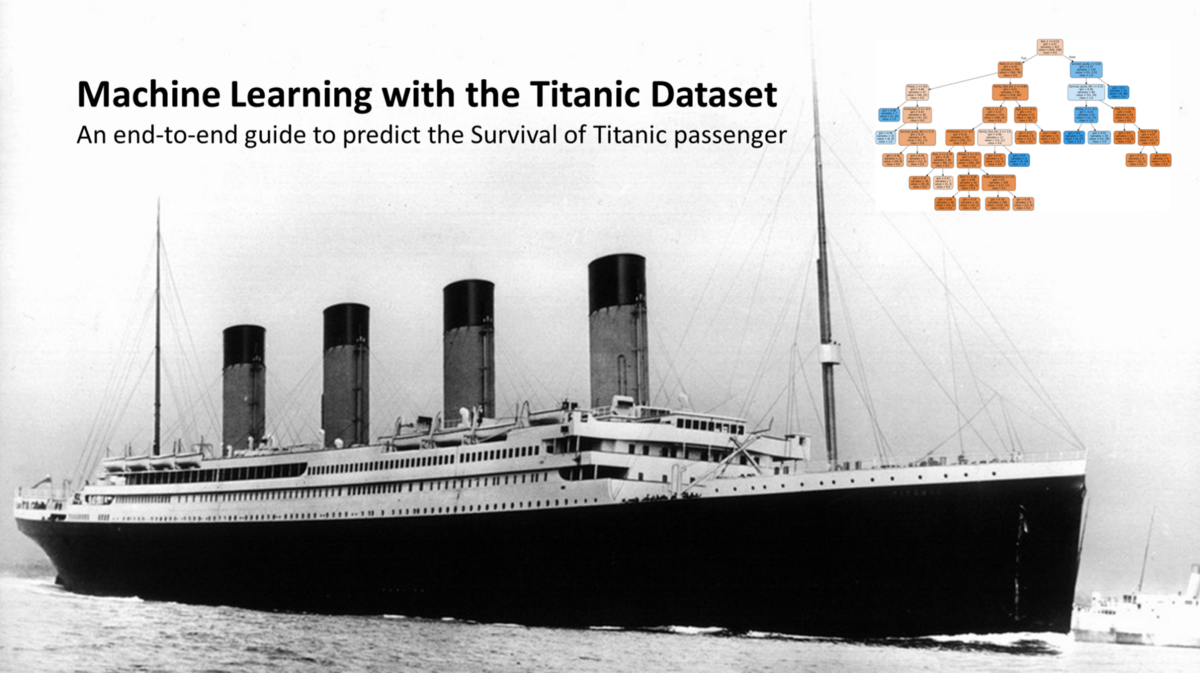

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
pd.set_option("display.max_columns",100)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
df1=pd.read_csv("/kaggle/input/titanic/train.csv")
df2=pd.read_csv("/kaggle/input/titanic/test.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/titanic/train.csv'

In [ ]:
df=pd.concat([df1,df2],ignore_index=True)

<a id="3"></a>
<h1 style="background-color:red;font-family:newtimeroman;font-size:250%;text-align:center;border-radius: 10px 10px;">Exploratory Dataset</h1>

In [4]:
df

NameError: name 'df' is not defined

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


In [ ]:
df.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [ ]:
df.shape

(1309, 12)

<a id="4"></a>
<h1 style="background-color:red;font-family:newtimeroman;font-size:250%;text-align:center;border-radius: 10px 10px;">EDA</h1>

In [ ]:
df.Name.value_counts()

Connolly, Miss. Kate                                   2
Kelly, Mr. James                                       2
Braund, Mr. Owen Harris                                1
Johnson, Master. Harold Theodor                        1
Gustafsson, Mr. Alfred Ossian                          1
                                                      ..
Carter, Miss. Lucile Polk                              1
Silvey, Mr. William Baird                              1
Kallio, Mr. Nikolai Erland                             1
Louch, Mrs. Charles Alexander (Alice Adelaide Slow)    1
Peter, Master. Michael J                               1
Name: Name, Length: 1307, dtype: int64

In [ ]:
df["Title"]=df["Name"].str.extract("([A-Za-z]+)\.",expand=False)
df['Title']=df['Title'].replace(['Ms','Mlle'],'Miss')
df['Title']=df['Title'].replace(['Mme','Countess','Lady','Dona'],'Mrs')
df['Title']=df['Title'].replace(['Dr','Major','Col','Capt','Sir','Rev','Jonkheer','Don'],'Mr')

<AxesSubplot:xlabel='Title', ylabel='count'>

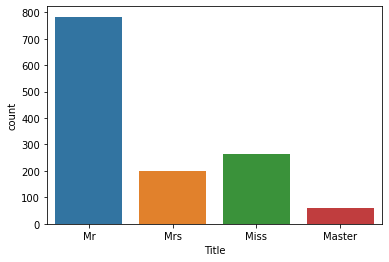

In [ ]:
df['Title'].value_counts()
sns.countplot(df["Title"])

In [ ]:
df["Age"].fillna(df.groupby("Title")["Age"].transform("median"),inplace=True)

In [ ]:
del df["Cabin"]

In [ ]:
df["Fare"].fillna(df["Fare"].median(),inplace=True)

In [ ]:
df['Family']=df['SibSp']+df['Parch']+1

<AxesSubplot:xlabel='Embarked', ylabel='count'>

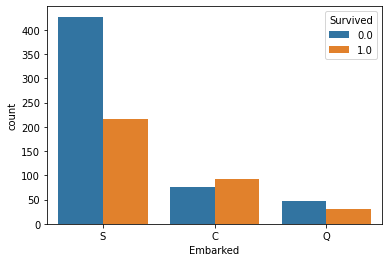

In [ ]:
sns.countplot(df["Embarked"],hue=df["Survived"])

In [ ]:
df["Embarked"]=df["Embarked"].fillna("S")

In [ ]:
df.drop(['Ticket'],axis=1,inplace=True)

In [ ]:
df.drop("Name",axis=1,inplace=True)

In [ ]:
df=pd.get_dummies(df,drop_first=True)

In [ ]:
df.shape

(1309, 14)

In [ ]:
x,y=df[:891].drop("Survived",axis=1),df[:891][["Survived"]]

In [ ]:
x.shape,y.shape

((891, 13), (891, 1))

<a id="5"></a>
<h1 style="background-color:red;font-family:newtimeroman;font-size:250%;text-align:center;border-radius: 10px 10px;">Prediction</h1>

In [ ]:
def result_func(model,count):
    predict_x=model.predict(df[891:].drop("Survived",axis=1))
    result_dataset=pd.DataFrame()
    result_dataset["PassengerId"]=df[891:]["PassengerId"]
    result_dataset["Predict"]=predict_x
    result_dataset["Survived"]=result_dataset["Predict"].map(lambda s:1 if s>=0.5 else 0 )
    print(result_dataset["Survived"].value_counts().plot.bar())
    result_dataset.drop("Predict",axis=1).to_csv("titanic_deep_learning_result_model{}.csv".format(count),index=False)
    return result_dataset 

In [ ]:
model=Sequential()
model.add(Dense(13,activation='relu'))
model.add(Dense(9,activation='relu'))
model.add(Dense(6,activation='relu'))
model.add(Dense(3,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

2023-02-02 21:25:52.985626: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


In [ ]:
model.compile(loss='binary_crossentropy',optimizer="adam",metrics=["accuracy"])

In [ ]:
model.fit(x,y,epochs=200,batch_size=10,verbose=1)

2023-02-02 21:25:53.238824: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/200
90/90 [==============================] - 1s 2ms/step - loss: 0.6998 - accuracy: 0.6611
Epoch 2/200
90/90 [==============================] - 0s 2ms/step - loss: 0.6646 - accuracy: 0.6700
Epoch 3/200
90/90 [==============================] - 0s 2ms/step - loss: 0.6816 - accuracy: 0.6195
Epoch 4/200
90/90 [==============================] - 0s 2ms/step - loss: 0.6777 - accuracy: 0.6173
Epoch 5/200
90/90 [==============================] - 0s 2ms/step - loss: 0.6746 - accuracy: 0.6173
Epoch 6/200
90/90 [==============================] - 0s 2ms/step - loss: 0.6735 - accuracy: 0.6173
Epoch 7/200
90/90 [==============================] - 0s 2ms/step - loss: 0.6709 - accuracy: 0.6173
Epoch 8/200
90/90 [==============================] - 0s 2ms/step - loss: 0.6691 - accuracy: 0.6184
Epoch 9/200
90/90 [==============================] - 0s 3ms/step - loss: 0.6686 - accuracy: 0.6173
Epoch 10/200
90/90 [==============================] - 0s 2ms/step - loss: 0.6674 - accuracy: 0.6184
Epoch 11/

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 13)                182       
_________________________________________________________________
dense_1 (Dense)              (None, 9)                 126       
_________________________________________________________________
dense_2 (Dense)              (None, 6)                 60        
_________________________________________________________________
dense_3 (Dense)              (None, 3)                 21        
_________________________________________________________________
dense_4 (Dense)              (None, 1)                 4         
Total params: 393
Trainable params: 393
Non-trainable params: 0
_________________________________________________________________


In [ ]:
scores=model.evaluate(x,y)

28/28 [==============================] - 0s 2ms/step - loss: 0.5823 - accuracy: 0.7273


In [ ]:
print("%s: %.2f%%" % (model.metrics_names[1],scores[1]*100))

accuracy: 72.73%


AxesSubplot(0.125,0.125;0.775x0.755)


,PassengerId,Predict,Survived
891,892,0.284938,0
892,893,0.284938,0
893,894,0.284938,0
894,895,0.284938,0
895,896,0.514854,1
...,...,...,...
1304,1305,0.284938,0
1305,1306,0.621271,1
1306,1307,0.284938,0
1307,1308,0.284938,0


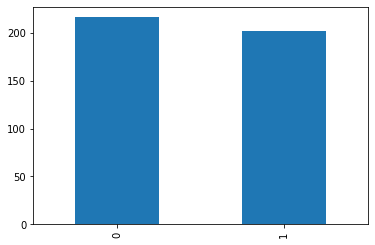

In [ ]:
result_func(model,1)

In [ ]:
history=model.fit(x,y,epochs=180,batch_size=10,verbose=1)

Epoch 1/180
90/90 [==============================] - 0s 2ms/step - loss: 0.6293 - accuracy: 0.6599
Epoch 2/180
90/90 [==============================] - 0s 2ms/step - loss: 0.5921 - accuracy: 0.7127
Epoch 3/180
90/90 [==============================] - 0s 2ms/step - loss: 0.5769 - accuracy: 0.7250
Epoch 4/180
90/90 [==============================] - 0s 2ms/step - loss: 0.5881 - accuracy: 0.7093
Epoch 5/180
90/90 [==============================] - 0s 2ms/step - loss: 0.5740 - accuracy: 0.7217
Epoch 6/180
90/90 [==============================] - 0s 2ms/step - loss: 0.5713 - accuracy: 0.7217
Epoch 7/180
90/90 [==============================] - 0s 2ms/step - loss: 0.5661 - accuracy: 0.7172
Epoch 8/180
90/90 [==============================] - 0s 2ms/step - loss: 0.5588 - accuracy: 0.7351
Epoch 9/180
90/90 [==============================] - 0s 2ms/step - loss: 0.5603 - accuracy: 0.7262
Epoch 10/180
90/90 [==============================] - 0s 2ms/step - loss: 0.5496 - accuracy: 0.7407
Epoch 11/

In [3]:
fig1=plt.figure(1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["loss"])
plt.title("Model Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Epoch")
plt.legend(["training", "testing"], loc= "upper left")

NameError: name 'history' is not defined

<Figure size 640x480 with 0 Axes>

In [ ]:
model=Sequential()
model.add(Dense(14,activation='relu'))
model.add(Dense(9,activation='relu'))
model.add(Dense(4,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [ ]:
model.compile(loss='binary_crossentropy',optimizer="adam",metrics=["accuracy"])

In [ ]:
model.fit(x,y,validation_split=0.2,epochs=150,batch_size=10,verbose=2)

Epoch 1/150
72/72 - 1s - loss: 9.5966 - accuracy: 0.5843 - val_loss: 0.7696 - val_accuracy: 0.3408
Epoch 2/150
72/72 - 0s - loss: 0.7170 - accuracy: 0.3890 - val_loss: 0.6981 - val_accuracy: 0.3575
Epoch 3/150
72/72 - 0s - loss: 0.6992 - accuracy: 0.3890 - val_loss: 0.6938 - val_accuracy: 0.3575
Epoch 4/150
72/72 - 0s - loss: 0.6940 - accuracy: 0.5744 - val_loss: 0.6891 - val_accuracy: 0.6425
Epoch 5/150
72/72 - 0s - loss: 0.6892 - accuracy: 0.6124 - val_loss: 0.6855 - val_accuracy: 0.6425
Epoch 6/150
72/72 - 0s - loss: 0.6865 - accuracy: 0.6124 - val_loss: 0.6818 - val_accuracy: 0.6425
Epoch 7/150
72/72 - 0s - loss: 0.6826 - accuracy: 0.6138 - val_loss: 0.6784 - val_accuracy: 0.6425
Epoch 8/150
72/72 - 0s - loss: 0.6793 - accuracy: 0.6138 - val_loss: 0.6753 - val_accuracy: 0.6425
Epoch 9/150
72/72 - 0s - loss: 0.6767 - accuracy: 0.6166 - val_loss: 0.6726 - val_accuracy: 0.6425
Epoch 10/150
72/72 - 0s - loss: 0.6799 - accuracy: 0.6110 - val_loss: 0.6705 - val_accuracy: 0.6425
Epoch 11/

In [ ]:
scores=model.evaluate(x,y)

28/28 [==============================] - 0s 1ms/step - loss: 0.5927 - accuracy: 0.6296


In [ ]:
print("%s: %.2f%%" % (model.metrics_names[1],scores[1]*100))

accuracy: 62.96%


AxesSubplot(0.125,0.125;0.775x0.755)


,PassengerId,Predict,Survived
891,892,0.402514,0
892,893,0.402514,0
893,894,0.197719,0
894,895,0.402514,0
895,896,0.402514,0
...,...,...,...
1304,1305,0.402514,0
1305,1306,0.402514,0
1306,1307,0.402514,0
1307,1308,0.402514,0


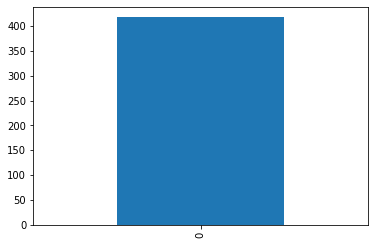

In [ ]:
result_func(model,2)

In [ ]:
history=model.fit(x,y,validation_split=0.2,epochs=200,batch_size=10,verbose=2)

Epoch 1/200
72/72 - 0s - loss: 0.6291 - accuracy: 0.6264 - val_loss: 0.6566 - val_accuracy: 0.6425
Epoch 2/200
72/72 - 0s - loss: 0.6306 - accuracy: 0.6264 - val_loss: 0.6571 - val_accuracy: 0.6425
Epoch 3/200
72/72 - 0s - loss: 0.6273 - accuracy: 0.6278 - val_loss: 0.6578 - val_accuracy: 0.6425
Epoch 4/200
72/72 - 0s - loss: 0.6386 - accuracy: 0.6278 - val_loss: 0.6573 - val_accuracy: 0.6425
Epoch 5/200
72/72 - 0s - loss: 0.6265 - accuracy: 0.6306 - val_loss: 0.6573 - val_accuracy: 0.6425
Epoch 6/200
72/72 - 0s - loss: 0.6210 - accuracy: 0.6278 - val_loss: 0.6586 - val_accuracy: 0.6425
Epoch 7/200
72/72 - 0s - loss: 0.6279 - accuracy: 0.6292 - val_loss: 0.6584 - val_accuracy: 0.6425
Epoch 8/200
72/72 - 0s - loss: 0.5992 - accuracy: 0.6306 - val_loss: 0.6597 - val_accuracy: 0.6425
Epoch 9/200
72/72 - 0s - loss: 0.5828 - accuracy: 0.6348 - val_loss: 0.6001 - val_accuracy: 0.6425
Epoch 10/200
72/72 - 0s - loss: 0.5719 - accuracy: 0.6348 - val_loss: 0.6315 - val_accuracy: 0.6425
Epoch 11/

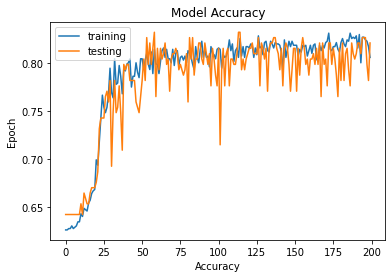

In [ ]:
fig1=plt.figure(1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Epoch")
plt.legend(["training", "testing"], loc= "upper left")

<function matplotlib.pyplot.show(close=None, block=None)>

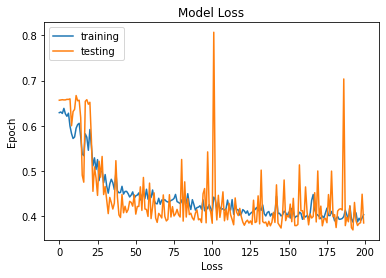

In [ ]:
fig1=plt.figure(2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.xlabel("Loss")
plt.ylabel("Epoch")
plt.legend(["training", "testing"], loc= "upper left")

plt.show

<a id="6"></a>
<h1 style="background-color:red;font-family:newtimeroman;font-size:250%;text-align:center;border-radius: 10px 10px;">Author Message</h1>

# Thanks for visiting my notebook

In this study, a solution was made for the titanic competition with the deep learning method and different scores were obtained.

ArithmeticError